<a href="https://colab.research.google.com/github/hasinduW/SE4050-waste-classification-4models/blob/EfficientNetB0/EfficientNetB0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/archive.zip'
extract_path = '/content/drive/MyDrive/Waste_Imag'

# Make sure extract_path exists
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    # List all files in the zip
    for member in zip_ref.namelist():
        # Remove the top-level folder name from path
        parts = member.split('/', 1)
        if len(parts) == 2:  # skip the top-level folder
            target_path = os.path.join(extract_path, parts[1])
            if not os.path.exists(os.path.dirname(target_path)):
                os.makedirs(os.path.dirname(target_path), exist_ok=True)
            with zip_ref.open(member) as source, open(target_path, "wb") as target:
                target.write(source.read())

print("Dataset extracted correctly to", extract_path)

Dataset extracted correctly to /content/drive/MyDrive/Waste_Imag


In [8]:
import os, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
                                     GlobalAveragePooling2D, BatchNormalization)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications import MobileNetV2
tf.__version__

'2.19.0'

In [14]:
# CONFIG
DATA_DIR = extract_path
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
VAL_SPLIT = 0.20
EPOCHS = 8
LR = 1e-4
SEED = 42
tf.keras.utils.set_random_seed(SEED)

assert os.path.isdir(DATA_DIR), f"Folder not found: {DATA_DIR}"


In [17]:
# STEP 2 — Data Generators
base_gen = ImageDataGenerator(rescale=1./255, validation_split=VAL_SPLIT)
aug_gen = ImageDataGenerator(
    rescale=1./255, validation_split=VAL_SPLIT,
    rotation_range=25, width_shift_range=0.2, height_shift_range=0.2,
    zoom_range=0.2, horizontal_flip=True, fill_mode='nearest'
)

train_base = base_gen.flow_from_directory(DATA_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
                                          class_mode='categorical', shuffle=True, subset='training', seed=SEED)

val_base = base_gen.flow_from_directory(DATA_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
                                        class_mode='categorical', shuffle=False, subset='validation', seed=SEED)

train_aug = aug_gen.flow_from_directory(DATA_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
                                        class_mode='categorical', shuffle=True, subset='training', seed=SEED)

val_aug = aug_gen.flow_from_directory(DATA_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
                                      class_mode='categorical', shuffle=False, subset='validation', seed=SEED)

class_names = list(train_base.class_indices.keys())
num_classes = len(class_names)
print("Classes:", class_names)

class_names = list(train_base.class_indices.keys())
num_classes = len(class_names)
print("Classes:", class_names)


Found 6593 images belonging to 9 classes.
Found 1642 images belonging to 9 classes.
Found 6593 images belonging to 9 classes.
Found 1642 images belonging to 9 classes.
Classes: ['Aluminium', 'Carton', 'E-waste', 'Glass', 'Organic_Waste', 'Paper_and_Cardboard', 'Plastics', 'Textiles', 'Wood']
Classes: ['Aluminium', 'Carton', 'E-waste', 'Glass', 'Organic_Waste', 'Paper_and_Cardboard', 'Plastics', 'Textiles', 'Wood']


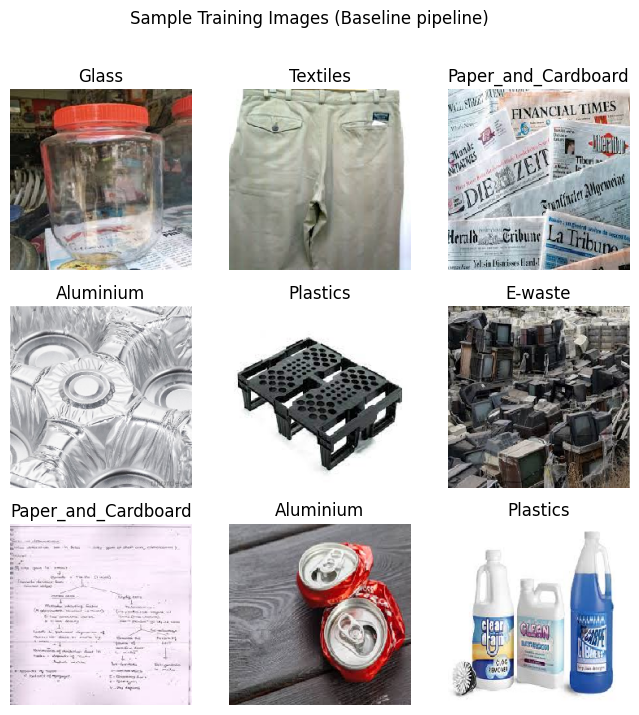

In [18]:
# STEP 3 — Peek some training data
x_batch, y_batch = next(train_base)
plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_batch[i])
    plt.title(class_names[np.argmax(y_batch[i])])
    plt.axis('off')
plt.suptitle("Sample Training Images (Baseline pipeline)")
plt.show()


In [19]:
# Utilities — plotting & evaluation helpers
def plot_history(history, title=""):
    plt.figure(figsize=(12,4))
    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title(f'{title} Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Acc'); plt.legend()
    # Loss
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{title} Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
    plt.show()

def eval_and_report(model, val_gen, title=""):
    # Evaluate
    loss, acc = model.evaluate(val_gen, verbose=0)
    print(f"{title} — Val Accuracy: {acc*100:.2f}% | Val Loss: {loss:.4f}")
    # Predict
    preds = model.predict(val_gen, verbose=0)
    pred_labels = np.argmax(preds, axis=1)
    true_labels = val_gen.classes
    # Confusion matrix
    cm = confusion_matrix(true_labels, pred_labels)
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(7,6))
    disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=45)
    plt.title(f'Confusion Matrix — {title}')
    plt.show()
    # Classification report
    print(classification_report(true_labels, pred_labels, target_names=class_names))

In [20]:
ckpt_dir = '/content/drive/MyDrive/Waste_Images/checkpoints'
os.makedirs(ckpt_dir, exist_ok=True)

def common_callbacks(tag):
    return [
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1),
        ModelCheckpoint(os.path.join(ckpt_dir, f'best_{tag}.keras'),
                        monitor='val_loss', save_best_only=True, verbose=1)
    ]

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model # Import Model

def build_efficientnet(input_shape=(224,224,3), classes=num_classes):
    base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=input_shape)
    base.trainable = False
    x = GlobalAveragePooling2D()(base.output)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.4)(x)
    out = Dense(classes, activation='softmax')(x)
    model = Model(base.input, out)
    model.compile(optimizer=Adam(LR), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

eff_model = build_efficientnet()
eff_model.summary()

hist_head = eff_model.fit(
    train_aug, epochs=EPOCHS_HEAD, validation_data=val_aug,
    callbacks=callbacks_efficientnet(), verbose=1
)
plot_history(hist_head, "EfficientNetB0 - Head Training")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 224, 224,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 224, 224,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,379,820 (16.71 MB)

 Trainable params: 330,249 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
166/207 ━━━━━━━━━━━━━━━━━━━━ 1:45 3s/step - accuracy: 0.1286 - loss: 2.2019